In [1]:
!pip install torchinfo -q

In [2]:
import os
import json
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.models import resnet34, ResNet34_Weights
from torchinfo import summary


from sklearn.model_selection import train_test_split

# Config

In [ ]:

path = '../data/ICPR 2026'
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Dataset config
vocab = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
num_classes = len(vocab)   # 36
label_len = 7
img_H, img_W = 32, 128

# Model config
embed_dim = 512
ff_dim = 512 * 4
num_layers = 3
num_heads = 8
drop_out = 0.1

# Training config
lr = 5e-4
batch_size = 64
epochs = 50
log_interval = 1
early_stop_count = 10
warmup_epochs = 3
train_loss = []
val_loss = []
train_acc = []
val_acc = []
best_model_path = '../weights/03_ResNet34_Transformer_OCR.pth'

# Set Seed

In [4]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

In [5]:
print(len(os.listdir(os.path.join(path, 'train', 'Scenario-A', 'Brazilian'))) * 10)
print(len(os.listdir(os.path.join(path, 'train', 'Scenario-A', 'Mercosur'))) * 10)
print(len(os.listdir(os.path.join(path, 'train', 'Scenario-B', 'Brazilian'))) * 10)
print(len(os.listdir(os.path.join(path, 'train', 'Scenario-B', 'Mercosur'))) * 10)

50000
50000
20000
80000


# Dataset

In [6]:
class ICPRDataSet(Dataset):
    def __init__(self, path, split='train', val_size=0.2, random_state=42, transform=None):
        self.transform = transform
        self.split = split
        self.degradation = self.get_degradation_transforms()

        if split in ['train', 'val', 'test']:
            data_path = os.path.join(path, 'train')
            all_tracks = self.get_path(data_path, split='train')
            train_tracks, temp_tracks = self.split_tracks(
                all_tracks, test_size=val_size, random_state=random_state
            )
            val_tracks, test_tracks = self.split_tracks(
                temp_tracks, test_size=0.5, random_state=random_state
            )
            if split == 'train':
                self.tracks = train_tracks
            elif split == 'val':
                self.tracks = val_tracks
            elif split == 'test':
                self.tracks = test_tracks
        elif split == 'blind_test':
            data_path = os.path.join(path, 'test')
            self.tracks = self.get_path(data_path, split='test')

        # Flatten thành list các entry, mỗi track tạo 2 entry khi train
        self.entries = self.build_entries(self.tracks)

        print(f'Split: {split}')
        print(f'Number of tracks: {len(self.tracks)}')
        print(f'Number of samples (entries): {len(self.entries)}')

    def get_path(self, path, split):
        tracks = {}
        track_paths = []

        if split == 'test':
            track_names = os.listdir(path)
            for track_name in track_names:
                track_paths.append(os.path.join(path, track_name))
        else:
            scennarios = ['Scenario-A', 'Scenario-B']
            countries = ['Brazilian', 'Mercosur']
            for scennario in scennarios:
                for countrie in countries:
                    data_path = os.path.join(path, scennario, countrie)
                    if not os.path.isdir(data_path):
                        continue
                    for track_name in os.listdir(data_path):
                        track_paths.append(os.path.join(data_path, track_name))

        for track_path in track_paths:
            track_id = os.path.basename(track_path)
            track_lr = []
            track_hr = []
            track_label = None

            for item in os.listdir(track_path):
                item_path = os.path.join(track_path, item)
                if item.lower().startswith('lr'):
                    track_lr.append(item_path)
                elif item.lower().startswith('hr'):
                    track_hr.append(item_path)
                elif item.lower().endswith('.json') and split != 'test':
                    with open(item_path, 'r', encoding='utf-8') as f:
                        annotations = json.load(f)
                    track_label = annotations.get('plate_text').strip()

            tracks[track_id] = {
                'track_path': track_path,
                'lr_paths': sorted(track_lr),
                'hr_paths': sorted(track_hr),
                'label': track_label
            }

        return tracks

    def split_tracks(self, tracks, test_size=0.1, random_state=42):
        track_ids = sorted(tracks.keys())
        train_ids, val_ids = train_test_split(
            track_ids,
            test_size=test_size,
            random_state=random_state,
            shuffle=True
        )
        train_tracks = {tid: tracks[tid] for tid in train_ids}
        val_tracks = {tid: tracks[tid] for tid in val_ids}
        return train_tracks, val_tracks

    def build_entries(self, tracks):
        entries = []
        for track_id, track in tracks.items():
            # Entry 1: LR gốc
            entries.append({
                'entry_id': track_id + '_lr',
                'paths': track['lr_paths'],
                'use_hr': False,
                'label': track['label']
            })
            # Entry 2: HR-degrade (chỉ train)
            if self.split == 'train' and len(track['hr_paths']) > 0:
                entries.append({
                    'entry_id': track_id + '_hr',
                    'paths': track['hr_paths'],
                    'use_hr': True,
                    'label': track['label']
                })
        return entries

    def get_degradation_transforms(self):
        return A.Compose([
            A.OneOf([
                A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                A.MotionBlur(blur_limit=(3, 5), p=1.0)
            ], p=0.7),
            A.OneOf([
                A.GaussNoise(noise_scale_factor=0.1, p=1.0),
                A.MultiplicativeNoise(multiplier=(0.9, 1.1), p=1.0)
            ], p=0.7),
            A.ImageCompression(quality_range=(20, 50), p=0.5),
            A.Downscale(scale_range=(0.3, 0.5), p=0.5) 
        ])

    
    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        entry = self.entries[idx]

        images = []
        for img_path in entry['paths']:          # luôn đúng 5 frames
            img = np.array(Image.open(img_path).convert('RGB'))

            if entry['use_hr']:
                img = self.degradation(image=img)['image']  # HR → pseudo-LR

            if self.transform is not None:
                img = self.transform(image=img)['image']

            images.append(img)

        return {
            'track_id': entry['entry_id'],
            'images': images,                    # luôn 5 phần tử
            'label': entry['label']
        }

In [7]:
train_transforms = A.Compose([
    A.Resize(height=img_H, width=img_W),
    A.Affine(
        scale=(0.95, 1.05),
        translate_percent=(0.05, 0.05),
        rotate=(-5, 5),
        fill=128,
        p=0.5
    ),
    A.Perspective(scale=(0.02, 0.05), p=0.3),
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),
    A.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=20,
            p=0.3
    ),
    A.ChannelShuffle(p=0.3),
    A.CoarseDropout(
            num_holes_range=(2, 5),
            hole_height_range=(4, 8),
            hole_width_range=(4, 8),
            p=0.3
    ),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

val_test_transforms = A.Compose([
    A.Resize(height=img_H, width=img_W),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

In [8]:
def encode_label(label: str) -> torch.Tensor:
    return torch.tensor(
        [vocab.index(c) for c in label.upper()],
        dtype=torch.long
    )  # shape (7,)

In [9]:
def collate_fn_train(batch):
    images = torch.stack([torch.stack(item['images']) for item in batch])
    # (B, F, C, H, W)
    targets = torch.stack([encode_label(item['label']) for item in batch])
    # (B, 7)
    return images, targets

def collate_fn_test(batch):
    images   = torch.stack([torch.stack(item['images']) for item in batch])
    targets  = torch.stack([encode_label(item['label']) for item in batch])
    track_ids = [item['track_id'] for item in batch]
    return images, targets, track_ids  

def collate_fn_blind_test(batch):
    images = torch.stack([torch.stack(item['images']) for item in batch])
    # (B, F, C, H, W)
    track_ids = [item['track_id'] for item in batch]
    return images, track_ids

In [10]:
train_dataset = ICPRDataSet(path, split='train', transform=train_transforms)
val_dataset = ICPRDataSet(path, split='val', transform=val_test_transforms)
test_dataset = ICPRDataSet(path, split='test', transform=val_test_transforms)
blind_test_dataset = ICPRDataSet(path, split='blind_test', transform=val_test_transforms)

Split: train
Number of tracks: 16000
Number of samples (entries): 32000
Split: val
Number of tracks: 2000
Number of samples (entries): 2000
Split: test
Number of tracks: 2000
Number of samples (entries): 2000
Split: blind_test
Number of tracks: 1000
Number of samples (entries): 1000


In [11]:




train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn_train, 
    num_workers=4,       
    pin_memory=True 
    
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn_train,
    num_workers=4,       
    pin_memory=True 
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn_test,
#     num_workers=4,       
#     pin_memory=True 
)

blind_test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn_blind_test)

In [12]:
def unnormalize(tensor):
    """tensor: (C, H, W)"""
    mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    std  = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


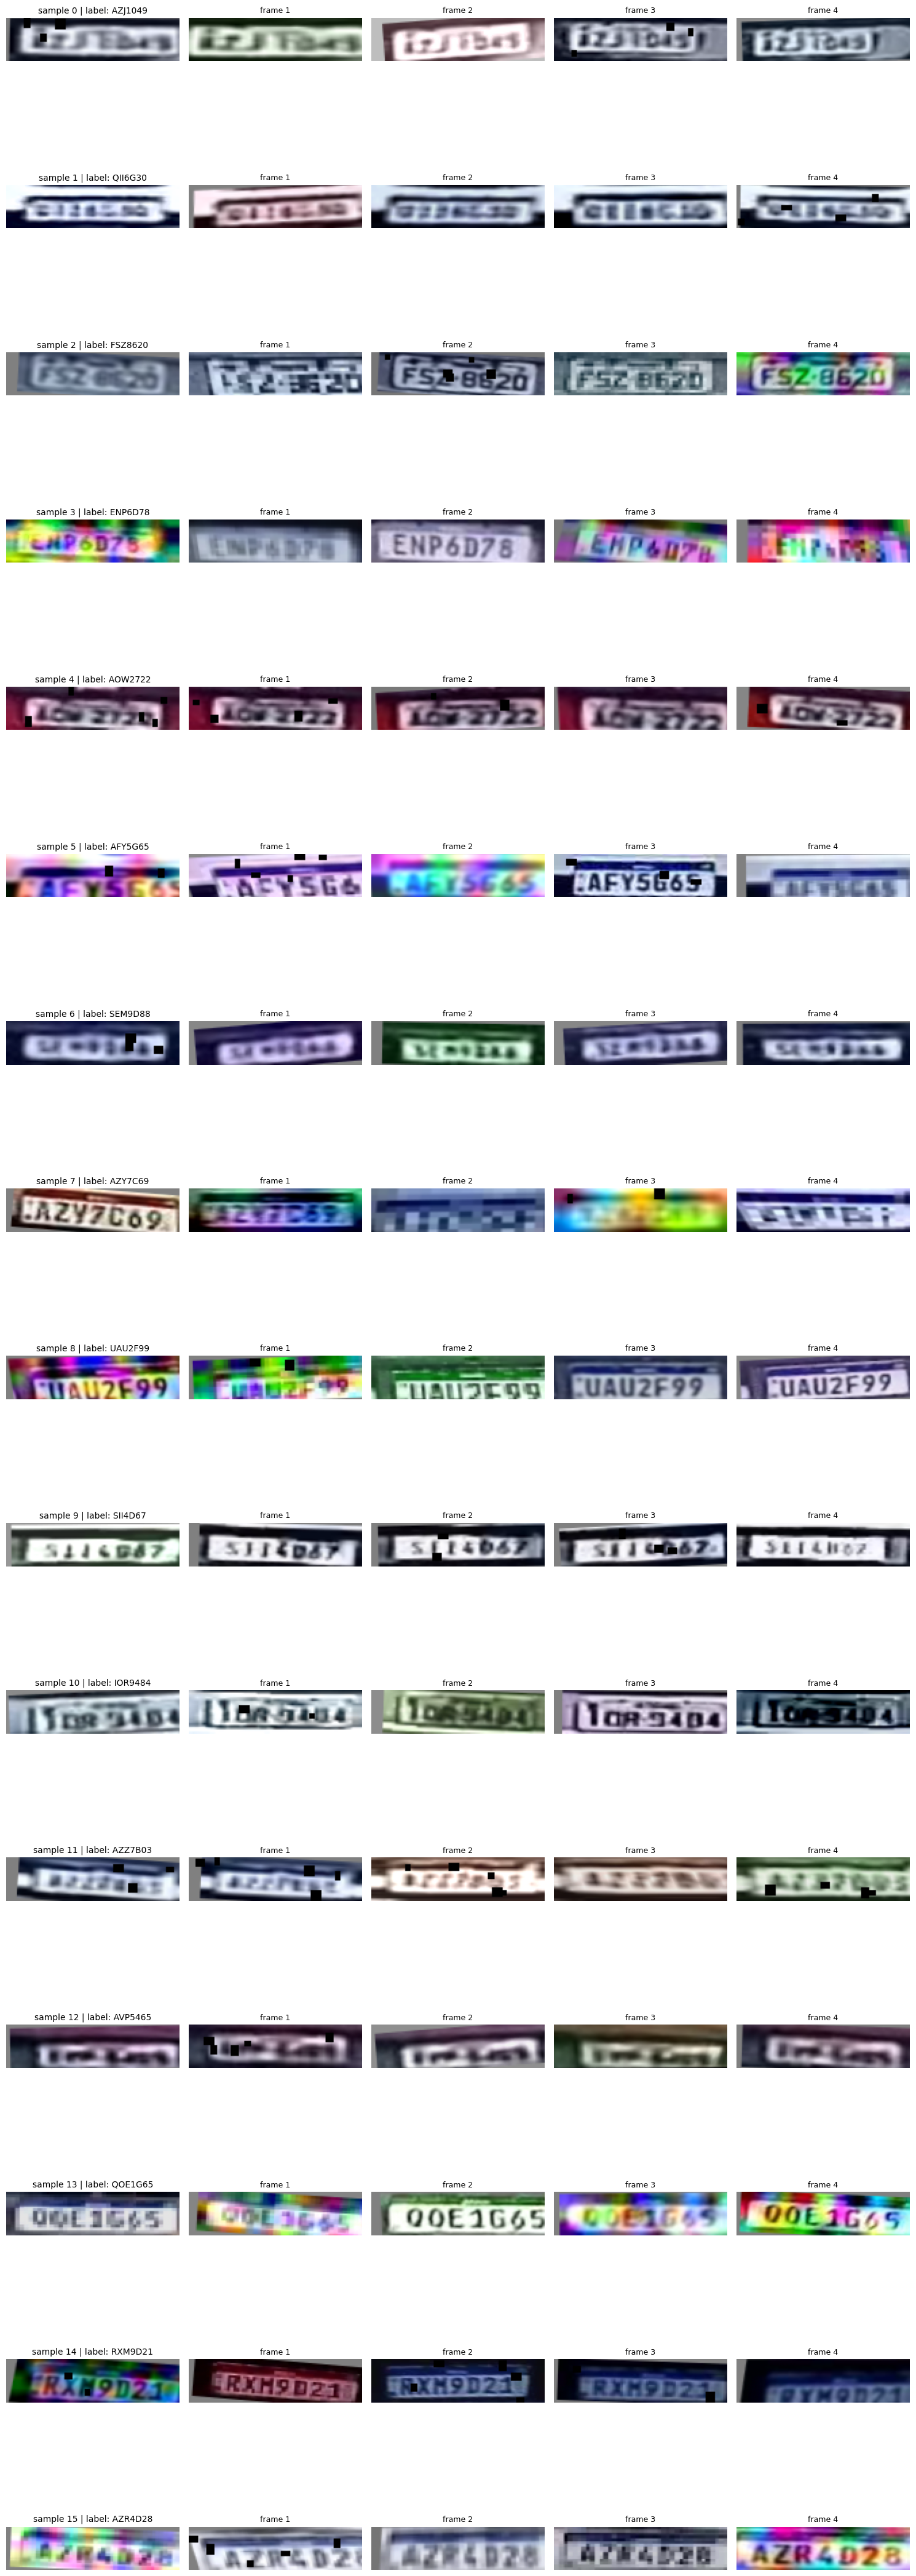

Batch shape: torch.Size([64, 5, 3, 32, 128]), Targets shape: torch.Size([64, 7])


In [13]:
# Visualize one batch from train_loader
images, targets = next(iter(train_loader))  # images: (B, F, C, H, W), targets: (B, 7)

B, Fm, C, H, W = images.shape
show_samples = min(16, B)
show_frames = min(5, Fm)

fig, axes = plt.subplots(show_samples, show_frames, figsize=(3 * show_frames, 2.8 * show_samples))

# Normalize axes shape for cases when rows/cols == 1
if show_samples == 1 and show_frames == 1:
    axes = np.array([[axes]])
elif show_samples == 1:
    axes = axes[np.newaxis, :]
elif show_frames == 1:
    axes = axes[:, np.newaxis]

for i in range(show_samples):
    label_str = ''.join(vocab[idx] for idx in targets[i].tolist())
    for j in range(show_frames):
        img = unnormalize(images[i, j].cpu())

        ax = axes[i, j]
        ax.imshow(img)
        ax.axis('off')
        if j == 0:
            ax.set_title(f'sample {i} | label: {label_str}', fontsize=10)
        else:
            ax.set_title(f'frame {j}', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Batch shape: {images.shape}, Targets shape: {targets.shape}')

# Baseline 2: Multi Frame ORC - ResNet34 + Transformer

In [14]:
class STNBlock(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.localization = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=5, stride=2, padding=2),
            nn.MaxPool2d(2, 2),
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(True),
            nn.AdaptiveAvgPool2d((4, 8))
        )
        self.fc_loc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 8, 128),
            nn.ReLU(True),
            nn.Linear(128, 6)
        )
        with torch.no_grad():
            self.fc_loc[-1].weight.zero_()
            self.fc_loc[-1].bias.copy_(
                torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float)
            )
    
    def forward(self, x):
        x = self.localization(x)
        x = self.fc_loc(x)
        x = x.view(-1, 2, 3)
        return x

In [15]:
class FeatureExtractor(nn.Module):
    def __init__(self, pretrained=True, out_dim=512, freeze_backbone=False):
        super().__init__()
        weights = ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = resnet34(weights=weights)

        self.conv1   = backbone.conv1
        self.bn1     = backbone.bn1
        self.relu    = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1  = backbone.layer1
        self.layer2  = backbone.layer2
        self.layer3  = backbone.layer3
        self.layer4  = backbone.layer4

        # Modify stride (2,2) -> (2,1): keep width, shrink height only
        # ResNet34 uses BasicBlock: stride is in conv1 (not conv2 like Bottleneck)
        self.layer3[0].conv1.stride = (2, 1)
        self.layer3[0].downsample[0].stride = (2, 1)
        self.layer4[0].conv1.stride = (2, 1)
        self.layer4[0].downsample[0].stride = (2, 1)

        # ResNet34 layer4 output = 512 channels -> project to out_dim
        self.proj = nn.Conv2d(512, out_dim, kernel_size=1)

        if freeze_backbone:
            for name, p in self.named_parameters():
                if 'proj' not in name:
                    p.requires_grad = False

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.proj(x)                              # (B, out_dim, H', W')
        x = F.adaptive_avg_pool2d(x, (1, None))       # (B, out_dim, 1, W')
        return x

In [16]:
class AttentionFusion(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.score_net = nn.Sequential(
            nn.Conv2d(channels, channels // 8, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // 8, 1, kernel_size=1)
        )

    def forward(self, x):
        total_frames, C, H, W = x.size()
        num_frames = 5
        batch_size = total_frames // num_frames

        # Reshape to [Batch_size, Frames, C, H, W]
        x_view = x.view(batch_size, num_frames, C, H, W)

        # Calculate attention scores [Batch_size, Frames, 1, H, W]
        scores = self.score_net(x).view(batch_size, num_frames, 1, H, W)
        weights = F.softmax(scores, dim=1)

        # Weight sim fusion
        fused_features = torch.sum(x_view * weights, dim=1)
        return fused_features

In [17]:
class pos_encoding(nn.Module):
    def __init__(self, embed_dim, max_length=500):
        super().__init__()
        self.pos_encoding = nn.Parameter(
            (embed_dim ** -0.5) * torch.randn(1, max_length, embed_dim)
        )

    def forward(self, x):
        B, T, C = x.shape
        return x + self.pos_encoding[:, :T, :]

In [18]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, ff_dim, num_heads, drop_out):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=drop_out, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.layernorm1 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.drop1 = nn.Dropout(drop_out)
        self.drop2 = nn.Dropout(drop_out)

    def forward(self, q, k, v):
        q_norm = self.layernorm1(q)
        k_norm = self.layernorm1(k)
        v_norm = self.layernorm1(v)

        attn_out, _ = self.attn(q_norm, k_norm, v_norm)
        attn_out = self.drop1(attn_out)
        out1 = attn_out + q

        out1_norm = self.layernorm2(out1)
        ff_out = self.ff(out1_norm)
        ff_out = self.drop2(ff_out)
        out2 = ff_out + out1

        return out2

In [19]:
class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, ff_dim, num_layers, num_heads, drop_out):
        super().__init__()

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim, ff_dim, num_heads, drop_out
            ) for _ in range(num_layers)
        ])

    def forward(self, x):
        output = x
        for block in self.blocks:
            output = block(output, output, output)
        return output

In [20]:
class ResTranOCR(nn.Module):
    def __init__(self, label_len, num_classes, embed_dim, ff_dim, num_layers, num_heads,
                 extractor_pretrained=True, freeze_extractor=True, drop_out=0.1):
        super().__init__()
        self.label_len = label_len
        self.stn           = STNBlock(3)
        self.extractor     = FeatureExtractor(pretrained=extractor_pretrained,
                                      out_dim=embed_dim,
                                      freeze_backbone=freeze_extractor)
        self.attn_fusion   = AttentionFusion(embed_dim)
        self.pos_encoder   = pos_encoding(embed_dim, max_length=5000)
        self.transformer_layer = TransformerEncoder(
            embed_dim, ff_dim, num_layers, num_heads, drop_out
        )
        self.head = nn.Linear(embed_dim, num_classes)  # 36

    def forward(self, x):
        B, Frames, C, H, W = x.size()

        x_flat    = x.view(B * Frames, C, H, W)
        theta     = self.stn(x_flat)
        grid      = F.affine_grid(theta, x_flat.size(), align_corners=False)
        x_aligned = F.grid_sample(x_flat, grid, align_corners=False)

        features  = self.extractor(x_aligned)       # (B*F, embed_dim, H', W')

        fused     = self.attn_fusion(features)       # (B, embed_dim, H', W')

        seq_input = fused.squeeze(2).permute(0, 2, 1)  # (B, W', out_dim)
        seq_input = self.pos_encoder(seq_input)
        seq_out   = self.transformer_layer(seq_input)   # (B, T, embed_dim)

        # Pool T timestep → đúng 7 vị trí
        # AdaptiveAvgPool hoạt động trên dim T
        seq_out = seq_out.permute(0, 2, 1)              # (B, embed_dim, T)
        seq_out = F.adaptive_avg_pool1d(seq_out, self.label_len)  # (B, embed_dim, 7)
        seq_out = seq_out.permute(0, 2, 1)              # (B, 7, embed_dim)

        out = self.head(seq_out)                        # (B, 7, 36)
        return out                                      

In [21]:
model = ResTranOCR(
    label_len=label_len,
    num_classes=num_classes,
    embed_dim=embed_dim,
    ff_dim=ff_dim,
    num_layers=num_layers,
    num_heads=num_heads,
    extractor_pretrained=True,
    freeze_extractor=True,
    drop_out=drop_out
    ).to(device)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 211MB/s]


In [22]:
summary(model, input_size=(1, 5, 3, img_H, img_W), device=device)

Layer (type:depth-idx)                             Output Shape              Param #
ResTranOCR                                         [1, 7, 36]                --
├─STNBlock: 1-1                                    [5, 2, 3]                 --
│    └─Sequential: 2-1                             [5, 64, 4, 8]             --
│    │    └─Conv2d: 3-1                            [5, 32, 16, 64]           2,432
│    │    └─MaxPool2d: 3-2                         [5, 32, 8, 32]            --
│    │    └─ReLU: 3-3                              [5, 32, 8, 32]            --
│    │    └─Conv2d: 3-4                            [5, 64, 8, 32]            18,496
│    │    └─ReLU: 3-5                              [5, 64, 8, 32]            --
│    │    └─AdaptiveAvgPool2d: 3-6                 [5, 64, 4, 8]             --
│    └─Sequential: 2-2                             [5, 6]                    --
│    │    └─Flatten: 3-7                           [5, 2048]                 --
│    │    └─Linear: 3-8     

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=epochs, eta_min=1e-6
)

In [24]:
def decode_pred(logits):
    """logits: (B, 7, 36) → list of str"""
    indices = logits.argmax(dim=2)  # (B, 7)
    return ["".join(vocab[i] for i in seq.tolist()) for seq in indices]

In [25]:
def compute_accuracy(logits, targets):
    """Sequence accuracy — đúng cả 7 ký tự mới tính đúng"""
    preds = logits.argmax(dim=2)    # (B, 7)
    correct = (preds == targets).all(dim=1).sum().item()
    return correct / targets.size(0)

In [26]:
# For multi-gpu
if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)

model = model.to(device)

Using 2 GPUs


# Training

In [27]:
def visualize_val_samples(model, val_loader, device, n_samples=2):
    """Lấy batch đầu val, show n_samples — mỗi sample 1 hàng gồm frame 0."""
    model.eval()
    images, targets = next(iter(val_loader))
    images_dev = images[:n_samples].to(device)

    with torch.no_grad():
        logits = model(images_dev)                     # (n, 7, 36)

    preds = decode_pred(logits.cpu())                  # list of str
    gts   = [''.join(vocab[i] for i in t.tolist())
              for t in targets[:n_samples]]            # list of str

    fig, axes = plt.subplots(
        n_samples, 1,
        figsize=(6, 2.5 * n_samples)
    )
    if n_samples == 1:
        axes = [axes]

    for i in range(n_samples):
        ax = axes[i]
        img = unnormalize(images[i, 0].cpu())          # frame 0, (H,W,C)
        ax.imshow(img)
        ax.axis('off')

        correct = preds[i] == gts[i]
        color   = 'green' if correct else 'red'
        ax.set_title(
            f'GT: {gts[i]}   |   Pred: {preds[i]}',
            fontsize=11, color=color, fontweight='bold'
        )

    plt.suptitle('Val sample preview', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

In [ ]:
def train(model, optimizer, scheduler, criterion,
          train_loader, val_loader,
          epochs, early_stop_count, best_model_path,
          log_interval, warmup_epochs=0, device='cpu'):

    # best_val_loss = float('inf')
    best_val_acc = 0.0 # switch to acc for orc all 7 char 
    break_count   = 0
    train_loss_hist, val_loss_hist = [], []
    train_acc_hist,  val_acc_hist  = [], []

    base_model = model.module if isinstance(model, nn.DataParallel) else model

    if warmup_epochs > 0:
        for p in base_model.extractor.parameters():
            p.requires_grad = False
        print(f'Warmup: freeze extractor for first {warmup_epochs} epochs')

    for epoch in tqdm(range(epochs), desc='Epoch', position=0):

        if warmup_epochs > 0 and epoch == warmup_epochs:
            for p in base_model.extractor.parameters():
                p.requires_grad = True
            print(f'Unfreeze extractor at epoch {epoch}')

        # Train 
        model.train()
        if warmup_epochs > 0 and epoch < warmup_epochs:
            base_model.extractor.eval()

        epoch_loss = epoch_acc = 0

        for images, targets in tqdm(train_loader, desc='Train', position=1, leave=False):
            images  = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            logits = model(images)

            loss = criterion(logits.permute(0, 2, 1), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            epoch_loss += loss.item()
            epoch_acc  += compute_accuracy(logits.detach().cpu(), targets.cpu())

        train_loss_hist.append(epoch_loss / len(train_loader))
        train_acc_hist.append(epoch_acc  / len(train_loader))

        # Validation
        model.eval()
        epoch_loss = epoch_acc = 0

        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc='Val', position=1, leave=False):
                images  = images.to(device)
                targets = targets.to(device)

                logits = model(images)
                loss   = criterion(logits.permute(0, 2, 1), targets)

                epoch_loss += loss.item()
                epoch_acc  += compute_accuracy(logits.cpu(), targets.cpu())

        val_loss_hist.append(epoch_loss / len(val_loader))
        val_acc_hist.append(epoch_acc  / len(val_loader))

        scheduler.step()

        # Log + Visual 
        if epoch % log_interval == 0:
            print(
                f'| Epoch {epoch:3d} '
                f'| Train Loss {train_loss_hist[-1]:.4f}  Acc {train_acc_hist[-1]:.4f} '
                f'| Val Loss {val_loss_hist[-1]:.4f}  Acc {val_acc_hist[-1]:.4f} |'
            )
            visualize_val_samples(model, val_loader, device, n_samples=2)

        # Checkpoint + Early stop
        if val_acc_hist[-1] > best_val_acc:
            break_count   = 0
            best_val_acc = val_acc_hist[-1]
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     base_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_acc':         val_acc_hist[-1],
                'break_count':          break_count,
                'train_loss_hist':      train_loss_hist,
                'val_loss_hist':        val_loss_hist,
                'train_acc_hist':       train_acc_hist,
                'val_acc_hist':         val_acc_hist,
            }, best_model_path)
        else:
            break_count += 1

        if break_count >= early_stop_count:
            print(f'Early stop tại epoch {epoch} | best val loss: {best_val_acc:.4f}')
            break

        train_loss.append(train_loss_hist[-1])
        val_loss.append(val_loss_hist[-1])
        train_acc.append(train_acc_hist[-1])
        val_acc.append(val_acc_hist[-1])

    checkpoint = torch.load(best_model_path, map_location=device)

    base_model = model.module if isinstance(model, nn.DataParallel) else model
    base_model.load_state_dict(checkpoint['model_state_dict'], strict=True)

    model.eval()
    print('Training hoàn tất, đã load best model')

    return model, {
        'train_loss': train_loss_hist,
        'val_loss':   val_loss_hist,
        'train_acc':  train_acc_hist,
        'val_acc':    val_acc_hist,
    }

Warmup: freeze extractor for first 3 epochs


Epoch:   0%|          | 0/50 [00:00<?, ?it/s]

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   0 | Train Loss 2.2736  Acc 0.0005 | Val Loss 1.9226  Acc 0.0024 |


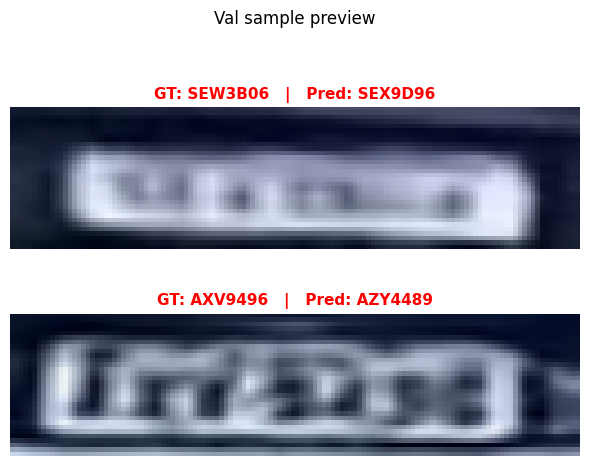

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   1 | Train Loss 1.5350  Acc 0.0183 | Val Loss 1.4721  Acc 0.0181 |


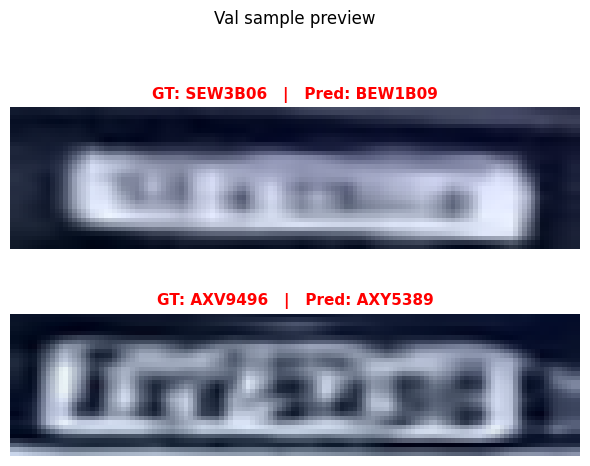

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   2 | Train Loss 1.2213  Acc 0.0605 | Val Loss 1.2588  Acc 0.0571 |


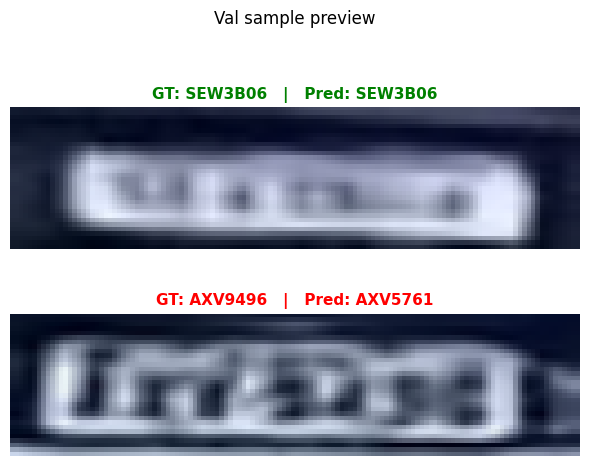

Unfreeze extractor at epoch 3


Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   3 | Train Loss 0.5076  Acc 0.5006 | Val Loss 0.5120  Acc 0.4478 |


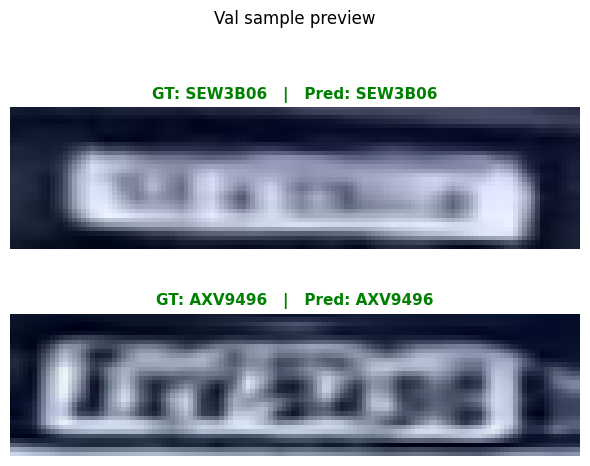

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   4 | Train Loss 0.2406  Acc 0.7101 | Val Loss 0.3791  Acc 0.5923 |


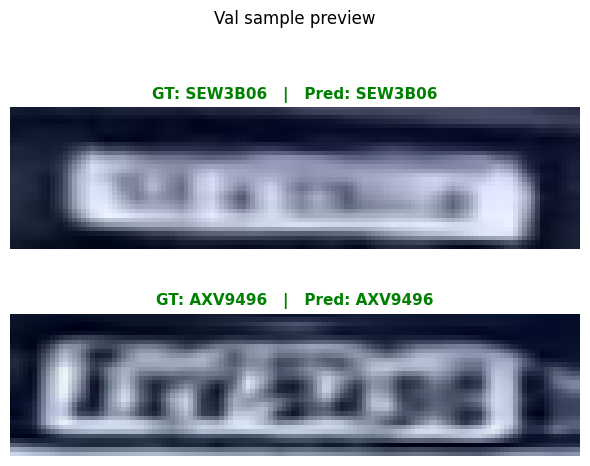

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   5 | Train Loss 0.1965  Acc 0.7564 | Val Loss 0.3583  Acc 0.6123 |


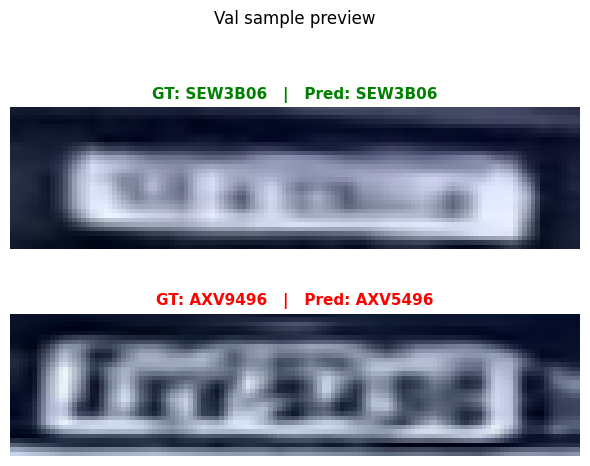

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   6 | Train Loss 0.1737  Acc 0.7812 | Val Loss 0.2910  Acc 0.6636 |


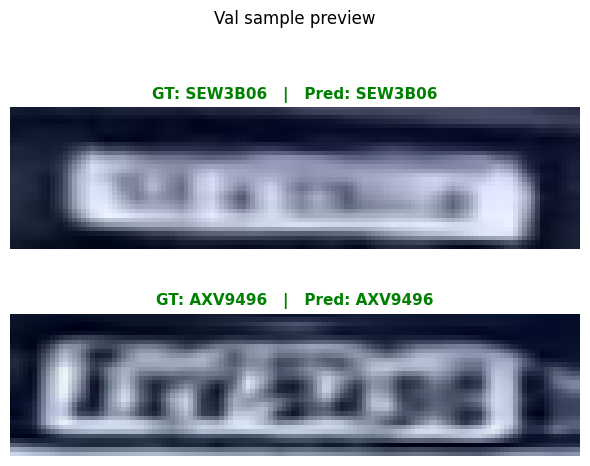

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   7 | Train Loss 0.1574  Acc 0.7963 | Val Loss 0.3308  Acc 0.6523 |


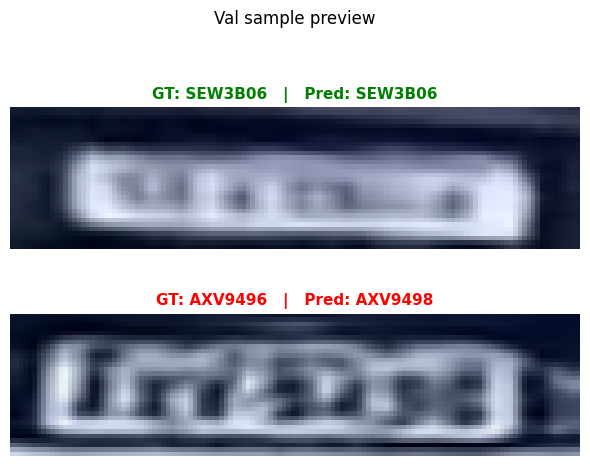

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   8 | Train Loss 0.1454  Acc 0.8104 | Val Loss 0.3188  Acc 0.6548 |


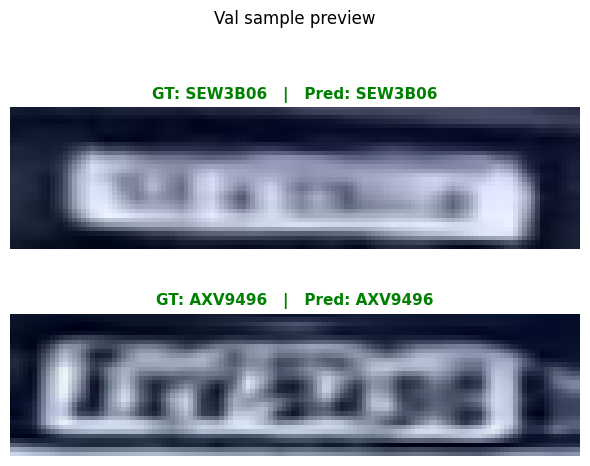

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch   9 | Train Loss 0.1336  Acc 0.8199 | Val Loss 0.3078  Acc 0.6558 |


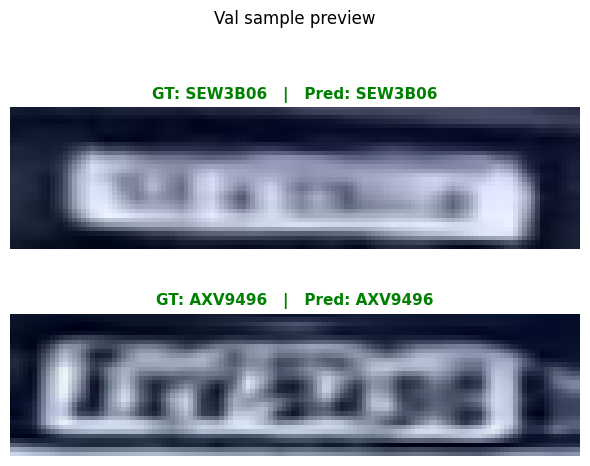

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  10 | Train Loss 0.1262  Acc 0.8293 | Val Loss 0.2983  Acc 0.6846 |


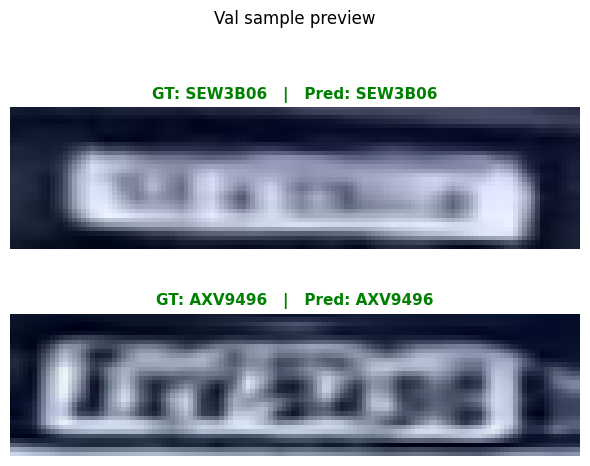

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  11 | Train Loss 0.1180  Acc 0.8345 | Val Loss 0.3046  Acc 0.6743 |


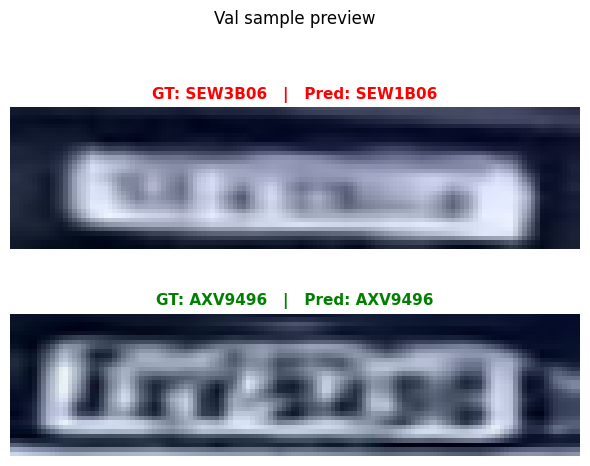

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  12 | Train Loss 0.1049  Acc 0.8537 | Val Loss 0.3085  Acc 0.6704 |


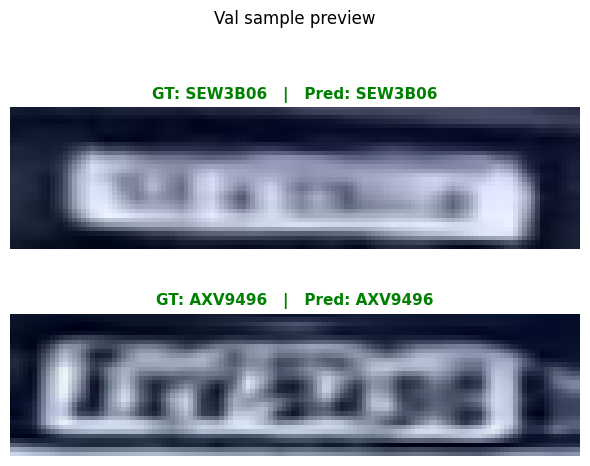

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  13 | Train Loss 0.0990  Acc 0.8559 | Val Loss 0.2864  Acc 0.7100 |


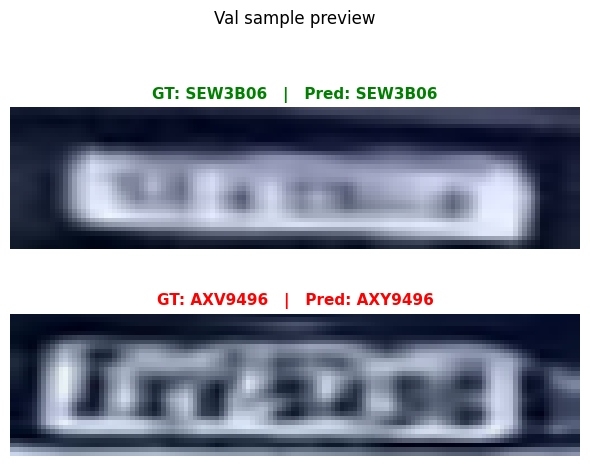

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  14 | Train Loss 0.0928  Acc 0.8631 | Val Loss 0.2950  Acc 0.7188 |


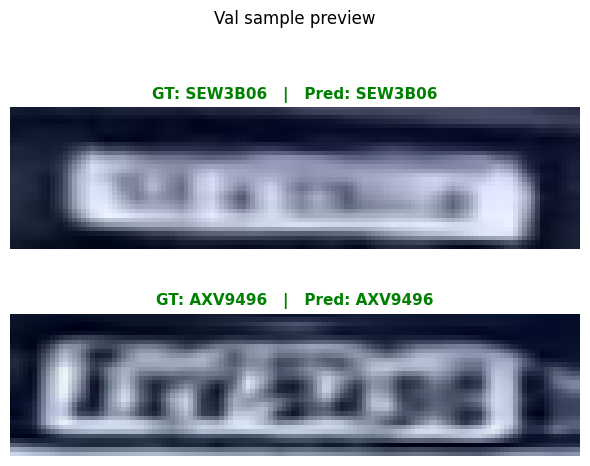

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  15 | Train Loss 0.0824  Acc 0.8755 | Val Loss 0.2960  Acc 0.7192 |


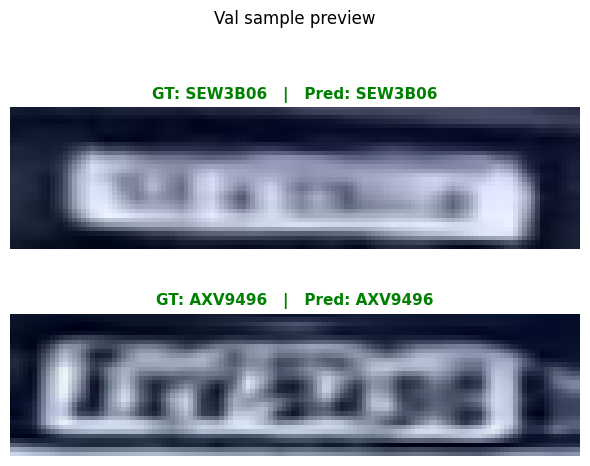

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  16 | Train Loss 0.0754  Acc 0.8834 | Val Loss 0.2725  Acc 0.7168 |


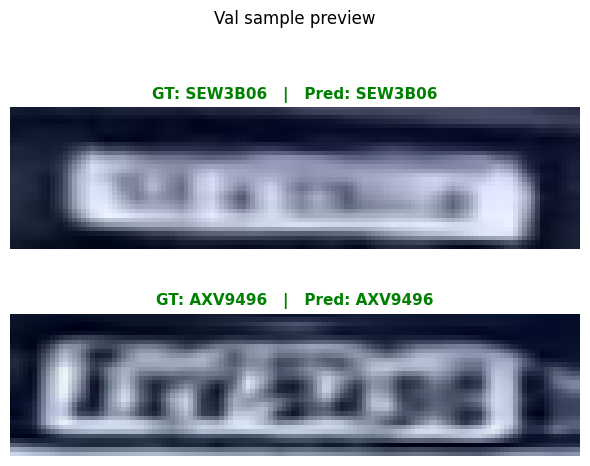

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  17 | Train Loss 0.0714  Acc 0.8872 | Val Loss 0.2886  Acc 0.7183 |


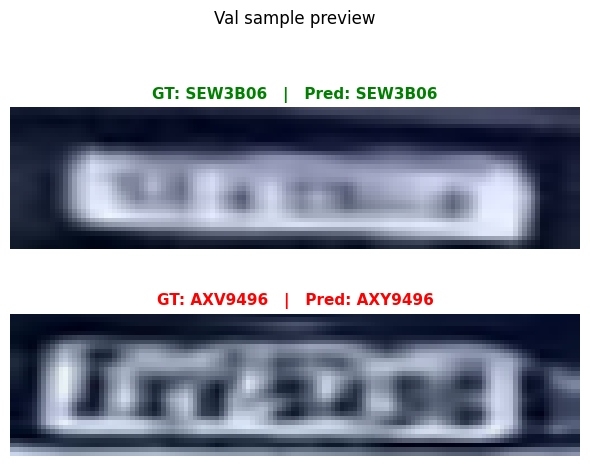

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  18 | Train Loss 0.0641  Acc 0.8985 | Val Loss 0.2855  Acc 0.7231 |


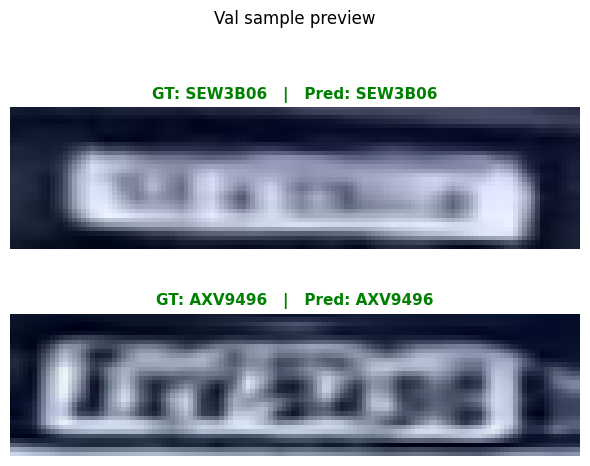

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  19 | Train Loss 0.0553  Acc 0.9094 | Val Loss 0.3045  Acc 0.7349 |


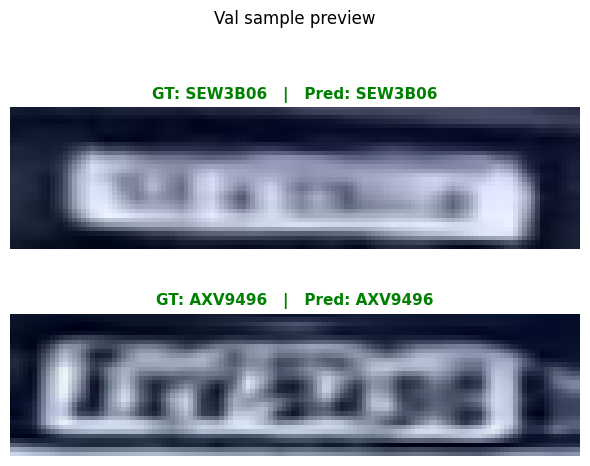

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  20 | Train Loss 0.0516  Acc 0.9146 | Val Loss 0.3129  Acc 0.7261 |


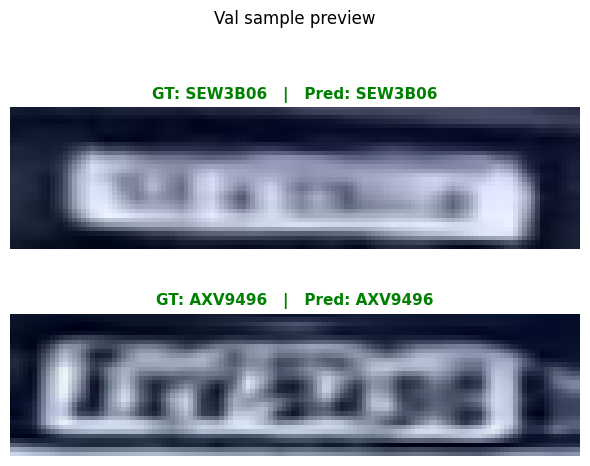

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  21 | Train Loss 0.0449  Acc 0.9223 | Val Loss 0.3213  Acc 0.7339 |


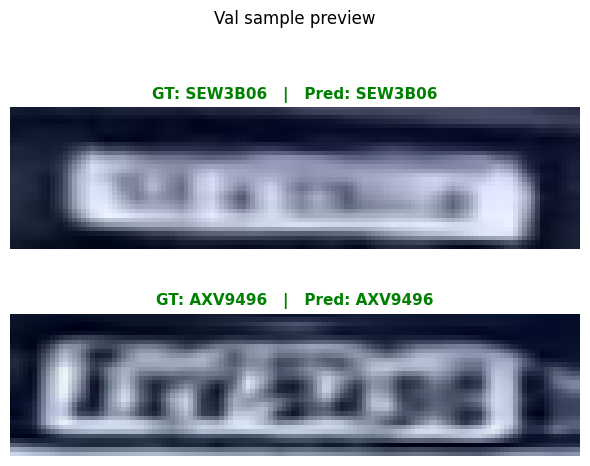

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  22 | Train Loss 0.0418  Acc 0.9258 | Val Loss 0.3199  Acc 0.7095 |


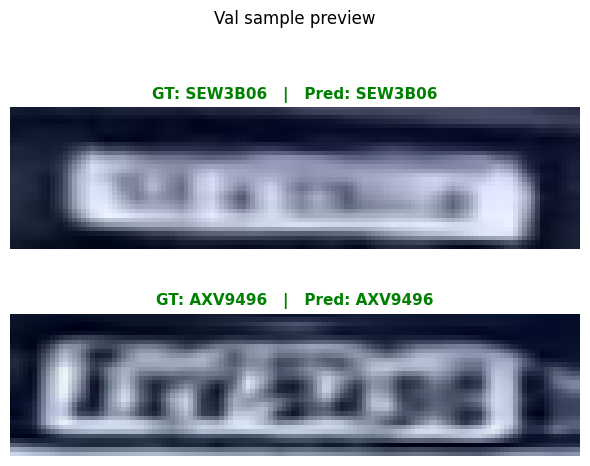

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  23 | Train Loss 0.0349  Acc 0.9351 | Val Loss 0.3261  Acc 0.7305 |


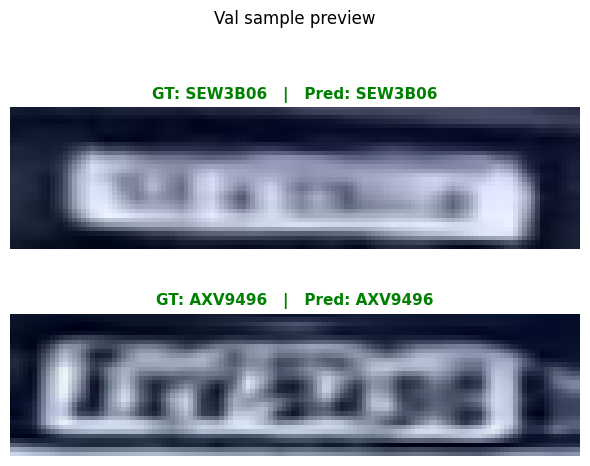

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  24 | Train Loss 0.0308  Acc 0.9421 | Val Loss 0.3432  Acc 0.7451 |


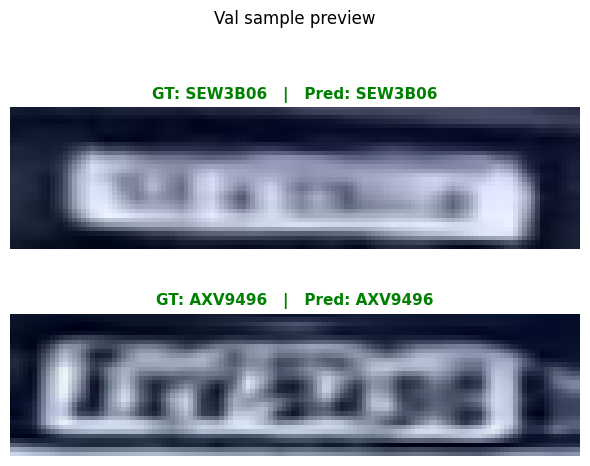

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  25 | Train Loss 0.0290  Acc 0.9446 | Val Loss 0.3421  Acc 0.7236 |


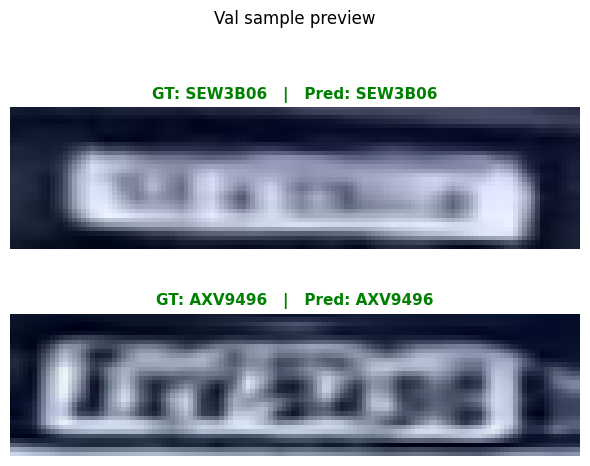

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  26 | Train Loss 0.0253  Acc 0.9506 | Val Loss 0.3441  Acc 0.7354 |


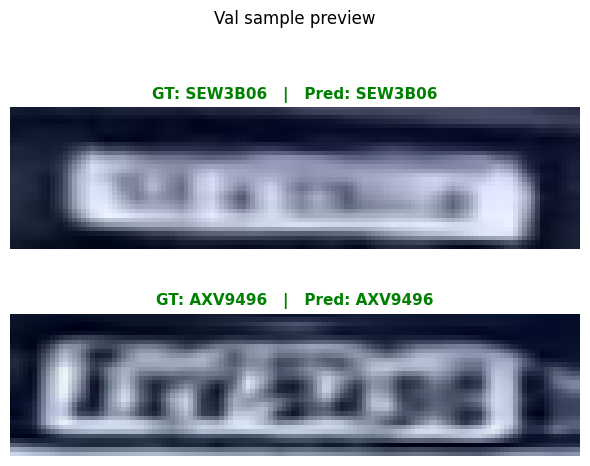

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  27 | Train Loss 0.0226  Acc 0.9572 | Val Loss 0.3537  Acc 0.7290 |


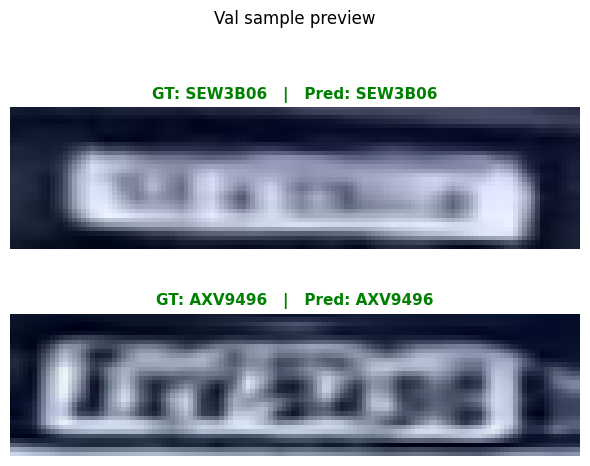

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  28 | Train Loss 0.0187  Acc 0.9613 | Val Loss 0.3519  Acc 0.7471 |


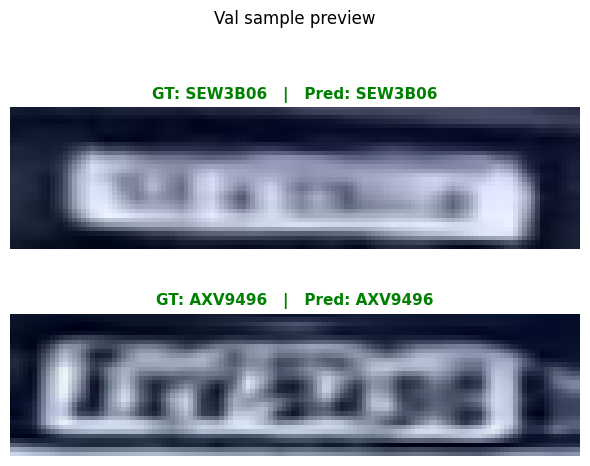

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:00<?, ?it/s]

| Epoch  29 | Train Loss 0.0166  Acc 0.9660 | Val Loss 0.3635  Acc 0.7520 |


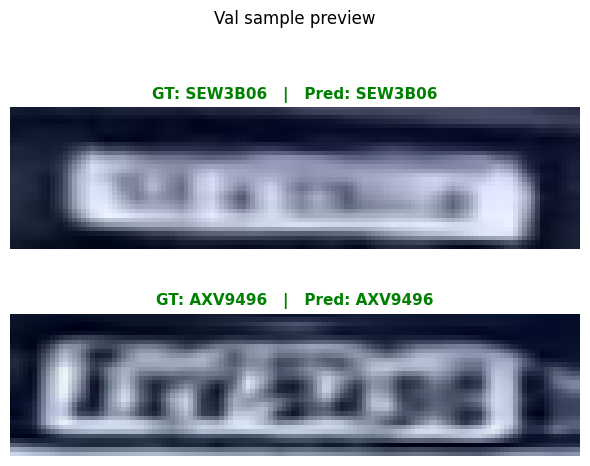

Train:   0%|          | 0/500 [00:00<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  30 | Train Loss 0.0146  Acc 0.9716 | Val Loss 0.3846  Acc 0.7456 |


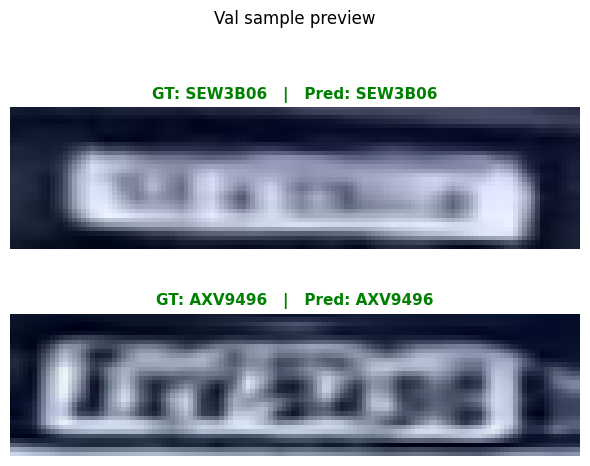

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  31 | Train Loss 0.0140  Acc 0.9729 | Val Loss 0.3633  Acc 0.7554 |


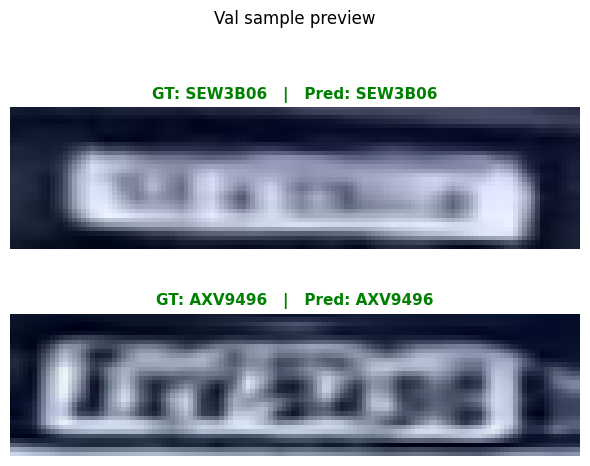

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  32 | Train Loss 0.0110  Acc 0.9778 | Val Loss 0.3805  Acc 0.7520 |


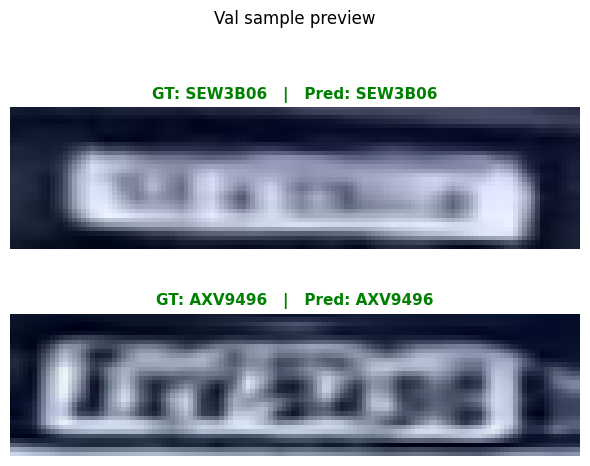

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  33 | Train Loss 0.0107  Acc 0.9778 | Val Loss 0.3857  Acc 0.7505 |


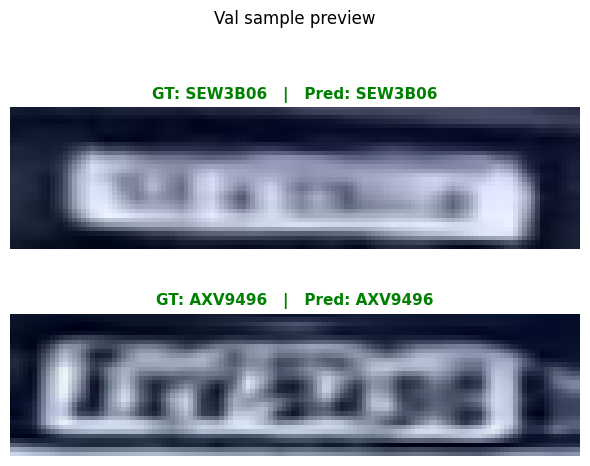

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  34 | Train Loss 0.0086  Acc 0.9820 | Val Loss 0.4007  Acc 0.7412 |


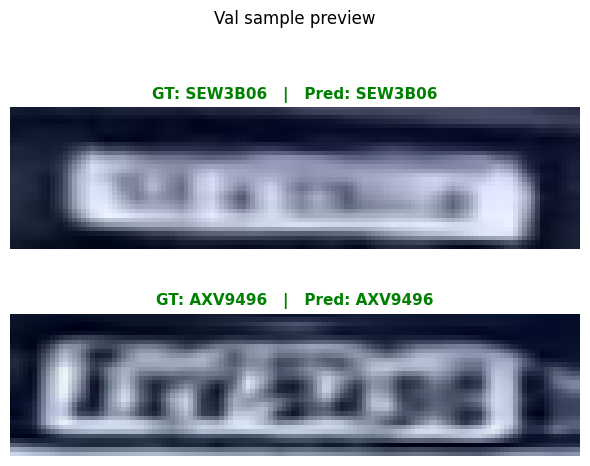

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  35 | Train Loss 0.0077  Acc 0.9844 | Val Loss 0.3724  Acc 0.7500 |


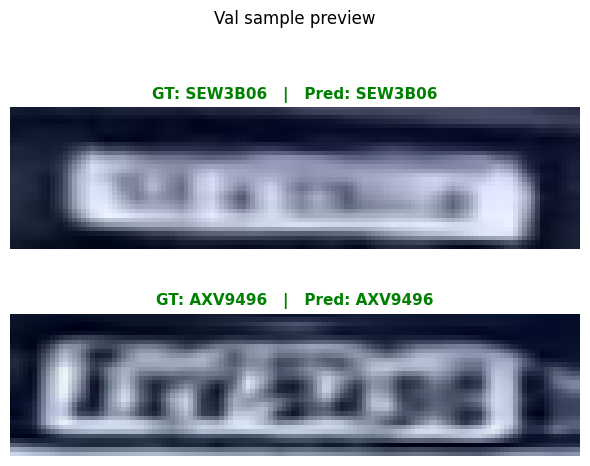

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  36 | Train Loss 0.0072  Acc 0.9851 | Val Loss 0.3922  Acc 0.7632 |


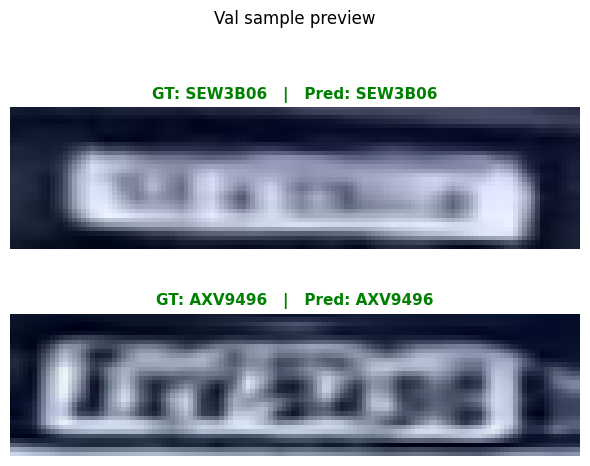

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  37 | Train Loss 0.0063  Acc 0.9876 | Val Loss 0.4046  Acc 0.7651 |


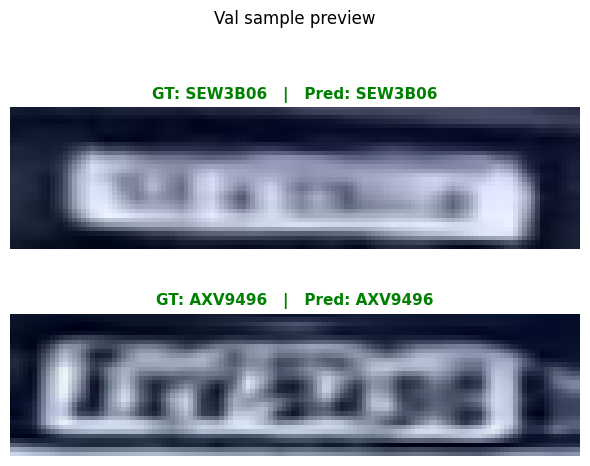

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  38 | Train Loss 0.0058  Acc 0.9886 | Val Loss 0.3963  Acc 0.7642 |


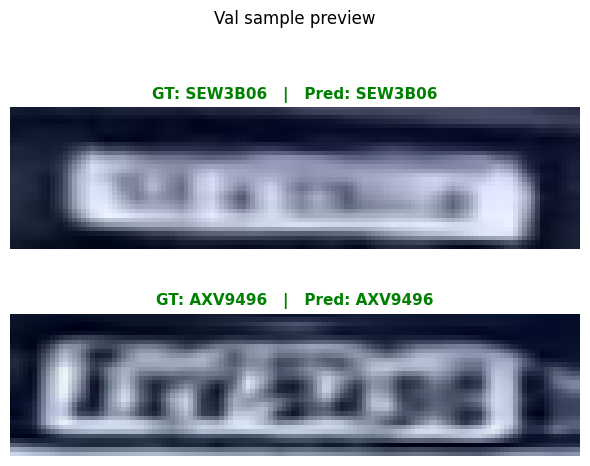

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  39 | Train Loss 0.0051  Acc 0.9903 | Val Loss 0.3851  Acc 0.7754 |


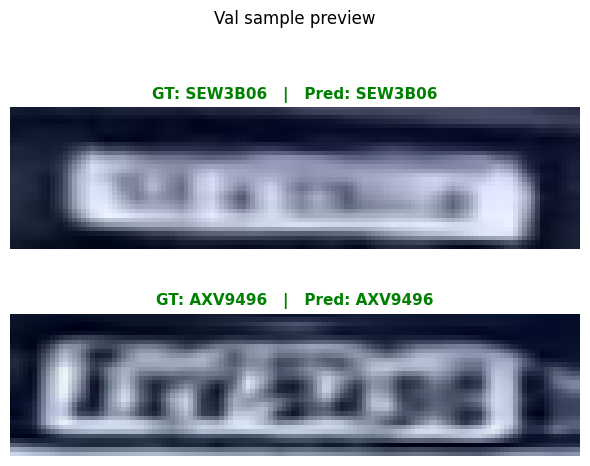

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  40 | Train Loss 0.0048  Acc 0.9900 | Val Loss 0.3889  Acc 0.7686 |


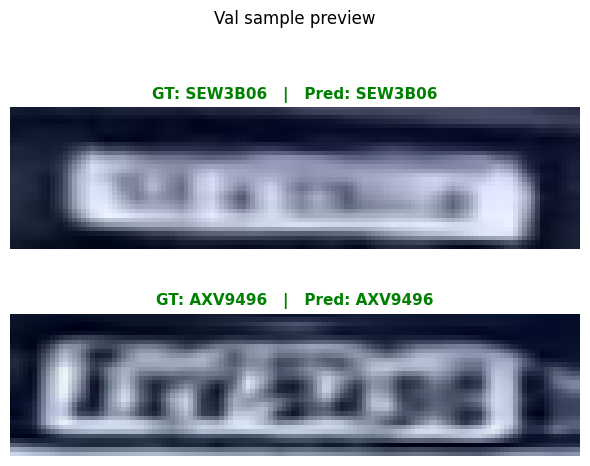

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  41 | Train Loss 0.0042  Acc 0.9919 | Val Loss 0.3887  Acc 0.7720 |


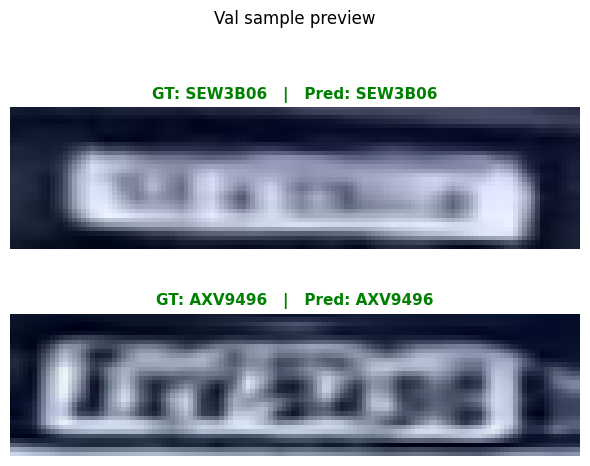

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  42 | Train Loss 0.0036  Acc 0.9928 | Val Loss 0.3998  Acc 0.7788 |


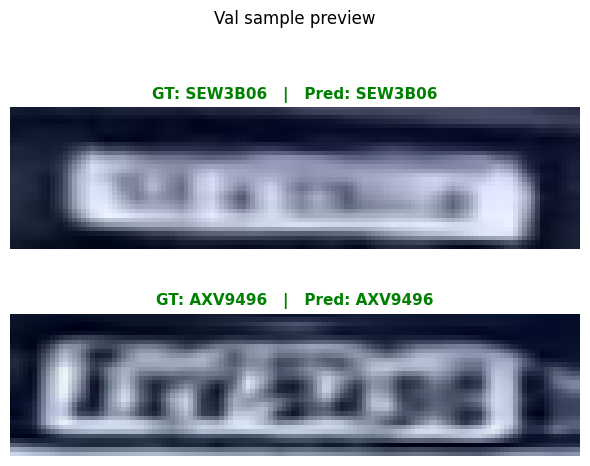

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  43 | Train Loss 0.0034  Acc 0.9932 | Val Loss 0.3955  Acc 0.7695 |


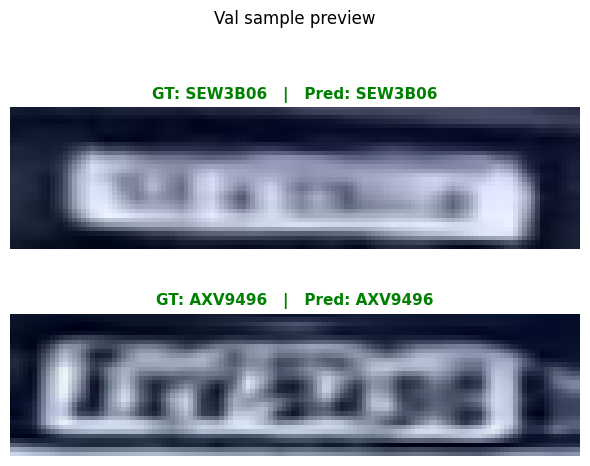

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  44 | Train Loss 0.0030  Acc 0.9939 | Val Loss 0.3914  Acc 0.7744 |


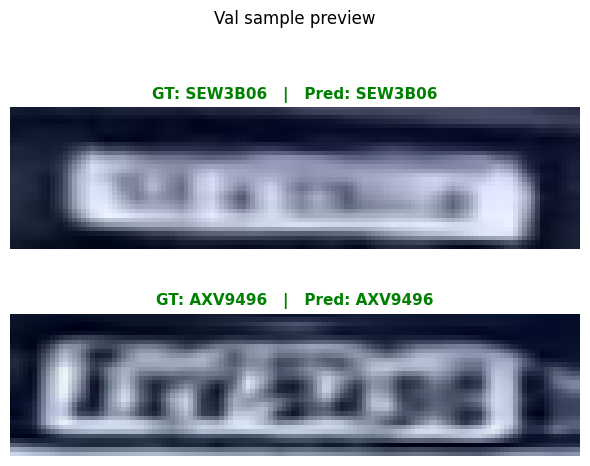

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  45 | Train Loss 0.0032  Acc 0.9941 | Val Loss 0.3900  Acc 0.7725 |


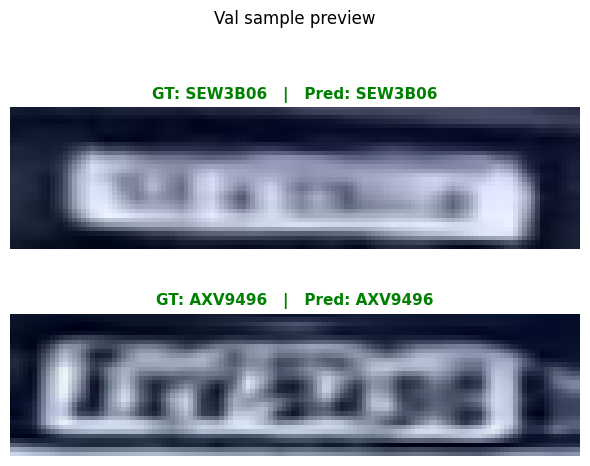

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  46 | Train Loss 0.0032  Acc 0.9941 | Val Loss 0.3888  Acc 0.7764 |


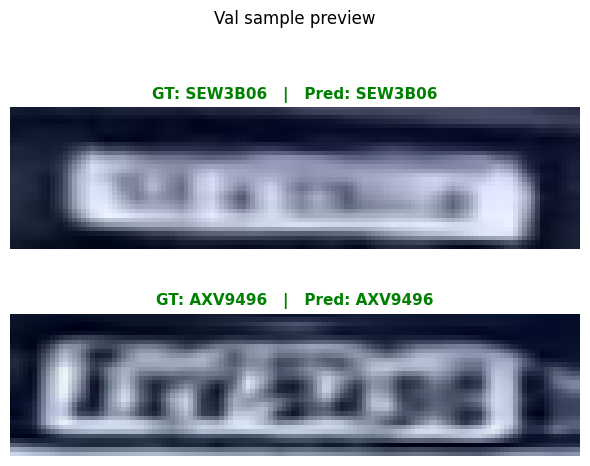

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  47 | Train Loss 0.0028  Acc 0.9944 | Val Loss 0.3893  Acc 0.7847 |


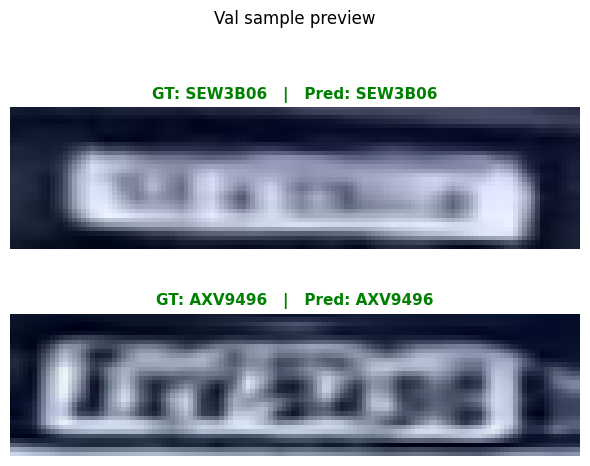

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  48 | Train Loss 0.0023  Acc 0.9954 | Val Loss 0.3917  Acc 0.7827 |


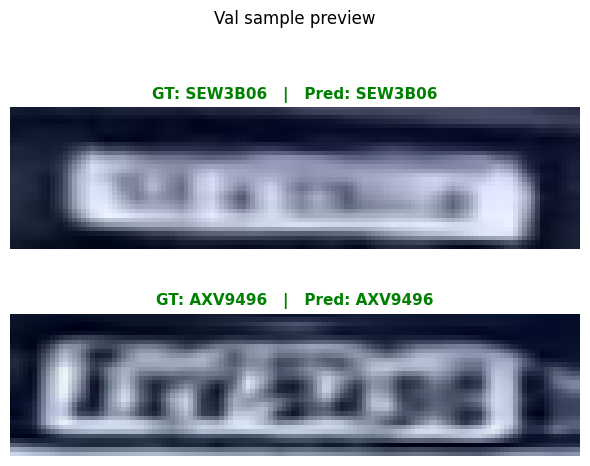

Train:   0%|          | 0/500 [00:01<?, ?it/s]

Val:   0%|          | 0/32 [00:01<?, ?it/s]

| Epoch  49 | Train Loss 0.0026  Acc 0.9947 | Val Loss 0.3921  Acc 0.7803 |


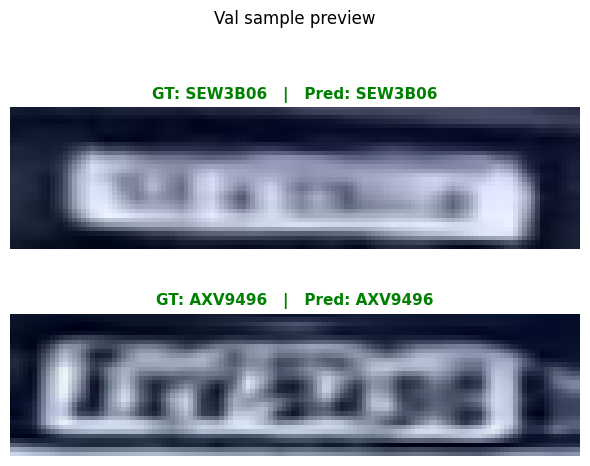

RuntimeError: Error(s) in loading state_dict for DataParallel:
	Missing key(s) in state_dict: "module.stn.localization.0.weight", "module.stn.localization.0.bias", "module.stn.localization.3.weight", "module.stn.localization.3.bias", "module.stn.fc_loc.1.weight", "module.stn.fc_loc.1.bias", "module.stn.fc_loc.3.weight", "module.stn.fc_loc.3.bias", "module.extractor.conv1.weight", "module.extractor.bn1.weight", "module.extractor.bn1.bias", "module.extractor.bn1.running_mean", "module.extractor.bn1.running_var", "module.extractor.layer1.0.conv1.weight", "module.extractor.layer1.0.bn1.weight", "module.extractor.layer1.0.bn1.bias", "module.extractor.layer1.0.bn1.running_mean", "module.extractor.layer1.0.bn1.running_var", "module.extractor.layer1.0.conv2.weight", "module.extractor.layer1.0.bn2.weight", "module.extractor.layer1.0.bn2.bias", "module.extractor.layer1.0.bn2.running_mean", "module.extractor.layer1.0.bn2.running_var", "module.extractor.layer1.1.conv1.weight", "module.extractor.la

In [29]:
model, metrics = train(
    model, optimizer, scheduler, criterion, train_loader, val_loader, epochs, early_stop_count,
    best_model_path, log_interval, warmup_epochs, device
)



# Visual loss/acc


In [ ]:
checkpoint = torch.load(best_model_path, map_location=device)
best_epoch = checkpoint.get('epoch', checkpoint)
state_dict = checkpoint.get('model_state_dict', checkpoint)
train_loss_hint = checkpoint.get('train_loss_hist', checkpoint)
val_loss_hint = checkpoint.get('val_loss_hist', checkpoint)
train_acc_hint = checkpoint.get('train_acc_hist', checkpoint)
val_acc_hint = checkpoint.get('val_acc_hist', checkpoint)

In [ ]:
def plot_result(num_epochs, train_accs, eval_accs, train_losses, eval_losses):
    epochs = list(range(num_epochs))
    fig, axs = plt.subplots(nrows = 1, ncols =2 , figsize = (12,6))
    axs[0].plot(epochs, train_accs, label = "Training")
    axs[0].plot(epochs, eval_accs, label = "Evaluation")
    axs[1].plot(epochs, train_losses, label = "Training")
    axs[1].plot(epochs, eval_losses, label = "Evaluation")
    axs[0].set_xlabel("Epochs")
    axs[1].set_xlabel("Epochs")
    axs[0].set_ylabel("Accuracy")
    axs[1].set_ylabel("Loss")
    plt.legend()


plot_result(
     best_epoch + 1,
    train_acc_hint,
    val_acc_hint,
    train_loss_hint,
    val_loss_hint
)

# Evalute

In [ ]:
checkpoint = torch.load(best_model_path, map_location=device)
state_dict = checkpoint.get('model_state_dict', checkpoint)

try:
    model.load_state_dict(state_dict)
except RuntimeError:
    if any(k.startswith('module.') for k in state_dict.keys()):
        state_dict = {k.replace('module.', '', 1): v for k, v in state_dict.items()}
    else:
        state_dict = {f'module.{k}': v for k, v in state_dict.items()}
    model.load_state_dict(state_dict)

model.eval()

In [ ]:
def visualize_predictions(model, loader, device='cpu', n_samples=6, mode='test'):
    """
    mode='test'       : hiện track_id, GT label, prediction (màu xanh/đỏ)
    mode='blind_test' : hiện track_id, prediction only
    """
    model.eval()

    batch = next(iter(loader))
    if mode == 'test':
        images, targets, track_ids = batch   # collate_fn_test phải trả thêm targets
    else:
        images, track_ids = batch

    images = images.to(device)
    with torch.no_grad():
        logits = model(images)
        preds  = decode_pred(logits.cpu())

    images_cpu = images.detach().cpu()
    n_samples  = min(n_samples, images_cpu.size(0))
    n_frames   = images_cpu.size(1)

    fig, axes = plt.subplots(
        n_samples, n_frames,
        figsize=(n_frames * 3, n_samples * 2.5)
    )
    if n_samples == 1:
        axes = [axes]

    for row_idx in range(n_samples):
        pred_label = preds[row_idx]
        track_id   = track_ids[row_idx]

        if mode == 'test':
            gt = ''.join(vocab[i] for i in targets[row_idx].tolist())
            correct = pred_label == gt
            color   = '#4CAF50' if correct else '#F44336'  # xanh nếu đúng, đỏ nếu sai
            title   = f'{track_id}\nGT: {gt}  |  Pred: {pred_label}'
        else:
            color = '#2196F3'
            title = f'{track_id}\nPred: {pred_label}'

        for col_idx in range(n_frames):
            ax  = axes[row_idx][col_idx]
            img = unnormalize(images_cpu[row_idx, col_idx])
            ax.imshow(img)
            ax.axis('off')
            ax.set_xlabel(f'frame {col_idx + 1}', fontsize=7, labelpad=2)

            if col_idx == 0:
                ax.set_title(title, fontsize=9, fontweight='bold',
                             color=color, loc='left', pad=3)

    plt.suptitle(
        f'{"Test" if mode == "test" else "Blind Test"} — Inference Preview',
        fontsize=12, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(f'inference_preview_{mode}.png', dpi=120, bbox_inches='tight')
    plt.show()

In [ ]:
visualize_predictions(model, test_loader, device=device, n_samples=30, mode='test')

In [ ]:
def evaluate_on_test(model, test_loader, device='cpu'):
    model.eval()

    total        = 0
    correct_raw  = 0
    correct_post = 0
    char_correct = 0
    char_total   = 0
    wrong_samples = []

    with torch.no_grad():
        for images, targets, track_ids in tqdm(test_loader, desc='Evaluating test set'):
            images  = images.to(device)
            logits  = model(images).cpu()           # (B, 7, 36)

            # Raw (không postprocess) — so sánh tensor
            preds_idx = logits.argmax(dim=2)        # (B, 7)
            B = targets.size(0)
            total        += B
            correct_raw  += (preds_idx == targets).all(dim=1).sum().item()
            char_correct += (preds_idx == targets).sum().item()
            char_total   += B * targets.size(1)

            # Postprocess — so sánh string
            preds_post = prediction_from_logits(logits)             
            gt_strs    = [''.join(vocab[i] for i in t.tolist()) for t in targets]
            correct_post += sum(p == g for p, g in zip(preds_post, gt_strs))

            # Thu thập mẫu sai (sau postprocess)
            for i in range(B):
                if preds_post[i] != gt_strs[i]:
                    wrong_samples.append({
                        'track_id': track_ids[i],
                        'gt':       gt_strs[i],
                        'pred_raw': ''.join(vocab[c] for c in preds_idx[i].tolist()),
                        'pred_post': preds_post[i]                  
                    })

    print(f"\n{'='*55}")
    print(f"  TEST SET EVALUATION")
    print(f"{'='*55}")
    print(f"  Sequence Acc (raw) : {correct_raw/total:.4f}  ({correct_raw}/{total})")
    print(f"  Sequence Acc (post): {correct_post/total:.4f}  ({correct_post}/{total})")  
    print(f"  Character Acc      : {char_correct/char_total:.4f}")
    print(f"  Wrong samples      : {len(wrong_samples)}")
    print(f"{'='*55}")

    if wrong_samples:
        print("\n  Sample wrong predictions (after postprocess):")
        for s in wrong_samples[:10]:
            print(f"  [{s['track_id']}]  GT: {s['gt']}  |  Raw: {s['pred_raw']}  |  Post: {s['pred_post']}")

    return {
        'seq_acc_raw':   correct_raw  / total,
        'seq_acc_post':  correct_post / total,
        'char_acc':      char_correct / char_total,
        'wrong_samples': wrong_samples
    }


# Chạy đánh giá
test_results = evaluate_on_test(model, test_loader, device=device)

In [ ]:
def predict_blind_test(model, test_loader, device='cpu', save_path='./test_predictions.csv', checkpoint_path=None):
    if checkpoint_path is not None:
        if not os.path.isfile(checkpoint_path):
            raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

        checkpoint = torch.load(checkpoint_path, map_location=device)
        state_dict = checkpoint.get('model_state_dict', checkpoint)

        # Handle DataParallel/non-DataParallel key mismatch automatically.
        try:
            model.load_state_dict(state_dict)
        except RuntimeError:
            if any(k.startswith('module.') for k in state_dict.keys()):
                state_dict = {k.replace('module.', '', 1): v for k, v in state_dict.items()}
            else:
                state_dict = {f'module.{k}': v for k, v in state_dict.items()}
            model.load_state_dict(state_dict)

        print(f'Loaded model weights from: {checkpoint_path}')

    model.eval()
    results = []

    with torch.no_grad():
        for images, track_ids in tqdm(test_loader, desc='Predict', leave=False):
            images = images.to(device)
            logits = model(images)
            preds = decode_pred(logits.cpu())

            for track_id, pred in zip(track_ids, preds):
                results.append({
                    'track_id': track_id,
                    'plate_text': pred
                })

    # Sort by numeric suffix if available (track_10005 -> 10005).
    def _sort_key(row):
        track_id = row['track_id']
        try:
            return int(track_id.split('_')[-1])
        except ValueError:
            return track_id

    results.sort(key=_sort_key)

    with open(save_path, 'w', encoding='utf-8') as f:
        f.write('track_id,plate_text\n')
        for row in results:
            f.write(f"{row['track_id']},{row['plate_text']}\n")

    print(f'Saved {len(results)} predictions to: {save_path}')
    return results


predict_blind_test(model, blind_test_loader, device)

In [ ]:
visualize_predictions(model, blind_test_loader, device=device, n_samples=16, mode='blind_test')